# Partie 1 : La base de données MNIST

## Plan de cette partie
- **1.1** - Le jeu de données (import, visualisation, préparation)
- **1.2.1** - Modèle linéaire (sans couche cachée)
- **1.2.2** - Modèle à plusieurs couches (réseau de neurones) MLP



## Imports

On commence par importer toutes les bibliothèques nécessaires.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# pour contrôler le hasard
np.random.seed(42)


C:\Users\Solene_NDS\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



## 1.1 - Le jeu de données

### 1.1.1 Chargement des données

On télécharge MNIST via sklearn. Chaque image est un vecteur $\vec{x}_i \in \mathbb{R}^{784}$ (28×28 pixels aplatis), et chaque label $y_i \in \{0, \ldots, 9\}$.

In [4]:
print("Chargement de MNIST ")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X = mnist.data.astype(np.float32)   # shape : (70000, 784)
y = mnist.target.astype(np.int32)   # shape : (70000,)

print(f" Donnees chargees")
print(f"   X.shape = {X.shape}  donc  {X.shape[0]} images, chacune représentée par {X.shape[1]} pixels")
print(f"   y.shape = {y.shape}")
print(f"   Valeurs de y possibles : {np.unique(y)}")
print(f"   Plage de valeurs de X : [{X.min()}, {X.max()}]")

Chargement de MNIST 
 Donnees chargees
   X.shape = (70000, 784)  donc  70000 images, chacune représentée par 784 pixels
   y.shape = (70000,)
   Valeurs de y possibles : [0 1 2 3 4 5 6 7 8 9]
   Plage de valeurs de X : [0.0, 255.0]


### 1.1.2 Visualisation de quelques exemples

Avant tout traitement, visualisons quelques images pour comprendre les données. Affichons 5 exemples par classe (0 à 9).

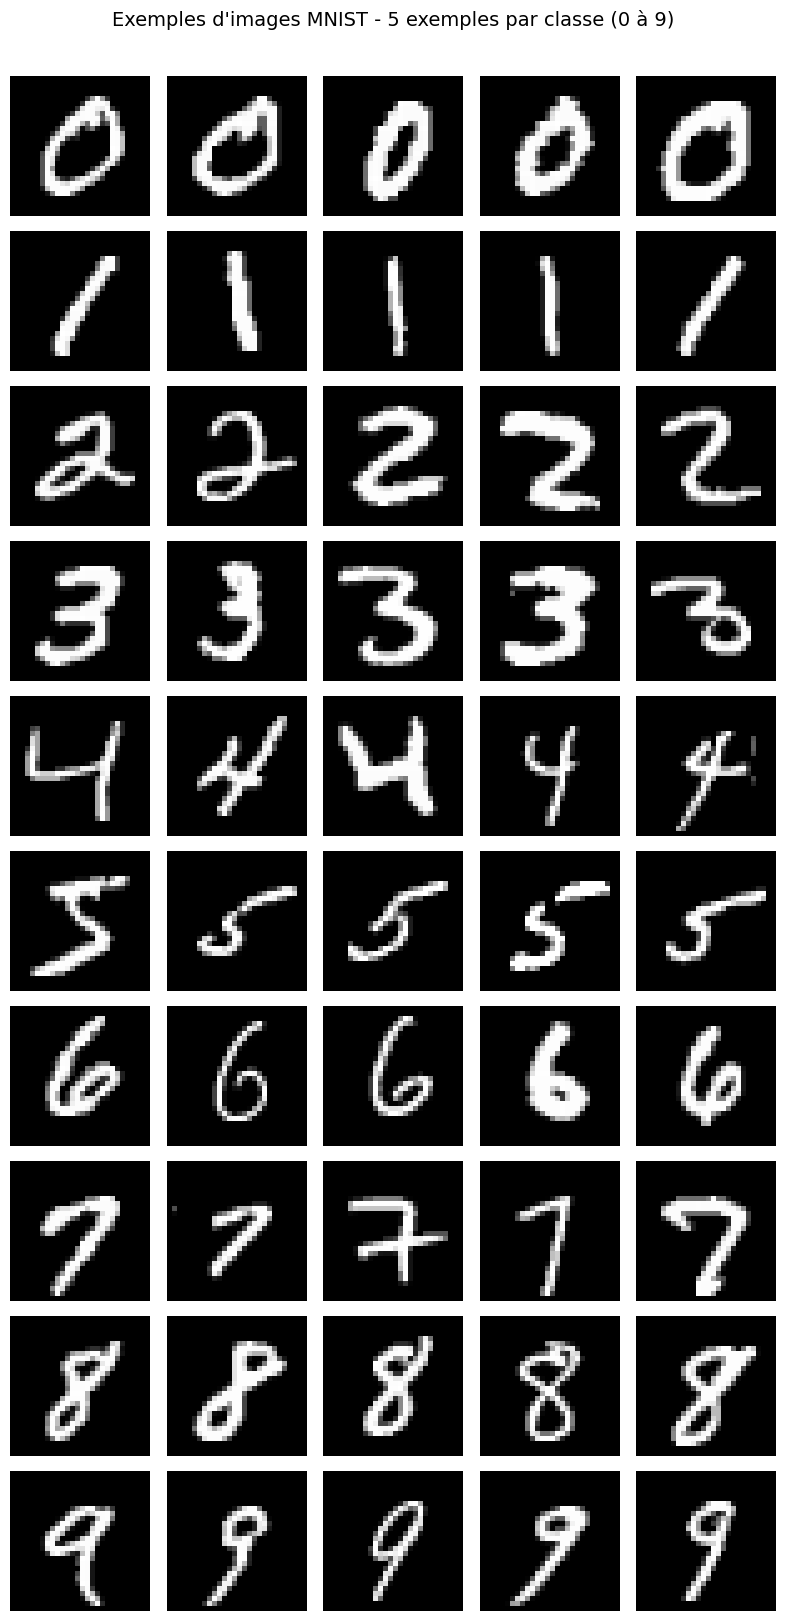

In [5]:
fig, axes = plt.subplots(10, 5, figsize=(8, 16))
fig.suptitle("Exemples d'images MNIST - 5 exemples par classe (0 à 9)", fontsize=14, y=1.01)

for classe in range(10):
    # Indices des images appartenant à cette classe
    indices_classe = np.where(y == classe)[0][:5]
    for col, idx in enumerate(indices_classe):
        ax = axes[classe, col]
        # On reshape le vecteur 784 en matrice 28×28 pour l'afficher
        ax.imshow(X[idx].reshape(28, 28), cmap='gray', vmin=0, vmax=255)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'Classe {classe}', fontsize=10, rotation=0,
                          labelpad=35, va='center')

plt.tight_layout()
plt.show()

### 1.1.3 Normalisation des données

Les pixels ont des valeurs dans $[0, 255]$. Pour améliorer la convergence des algorithmes, normalisons les données.

**Méthode utilisée : division par 255**  
Les valeurs passent dans $[0, 1]$. 


In [6]:
# Normalisation simple : division par 255
X_norm = X / 255.0

print(f"Avant normalisation : min={X.min():.1f}, max={X.max():.1f}, moyenne={X.mean():.2f}")
print(f"Après normalisation : min={X_norm.min():.3f}, max={X_norm.max():.3f}, moyenne={X_norm.mean():.4f}")

Avant normalisation : min=0.0, max=255.0, moyenne=33.39
Après normalisation : min=0.000, max=1.000, moyenne=0.1309


### 1.1.4 Séparation train / test

On divise les données en :
- **Ensemble d'entraînement** (60 000 images) : sert à ajuster les paramètres du modèle
- **Ensemble de test** (10 000 images) : sert à évaluer les performances *réelles* du modèle sur des données non vues



Ensemble d'entraînement : 60000 images
Ensemble de test        : 10000 images


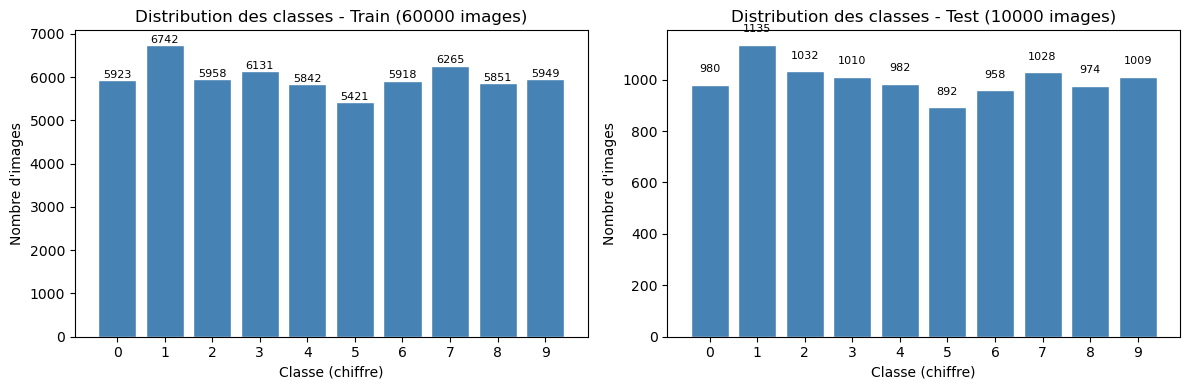


 Les classes sont plus ou moins bien équilibrées (6000 exemples par classe en train, 1000 en test environ)


In [7]:
X_train, X_test = X_norm[:60000], X_norm[60000:]
y_train, y_test = y[:60000],      y[60000:]

print(f"Ensemble d'entraînement : {X_train.shape[0]} images")
print(f"Ensemble de test        : {X_test.shape[0]} images")

# Vérification de la distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (data_y, titre) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    classes, counts = np.unique(data_y, return_counts=True)
    ax.bar(classes, counts, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution des classes - {titre} ({len(data_y)} images)')
    ax.set_xlabel('Classe (chiffre)')
    ax.set_ylabel('Nombre d\'images')
    ax.set_xticks(range(10))
    for c, n in zip(classes, counts):
        ax.text(c, n + 50, str(n), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("\n Les classes sont plus ou moins bien équilibrées (6000 exemples par classe en train, 1000 en test environ)")

---
## 1.2.1 - Modèle linéaire (sans couche cachée)


### Implémentation from scratch

On implémente :
1. La **fonction softmax** pour transformer les logits en probabilités
2. La **perte cross-entropie** (log-loss)
3. La **rétropropagation** et la descente de gradient

In [8]:
# FONCTIONS

def softmax(Z):
    """
    Transforme les logits Z (shape: N x K) en probabilités.
    
    softmax(z_k) = exp(z_k) / sum_j exp(z_j)
    """
    Z_stable = Z - np.max(Z, axis=1, keepdims=True)  
    exp_Z = np.exp(Z_stable)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)


def cross_entropy_loss(probs, y_true):
    """
    Perte cross-entropie : L = -1/N * sum_i log(P(y_i | x_i))
    
    probs  : shape (N, K) — probabilités softmax
    y_true : shape (N,)   — labels entiers
    """
    N = len(y_true)
    # On récupère la probabilité de la vraie classe pour chaque exemple
    log_probs = -np.log(probs[np.arange(N), y_true] + 1e-9)  # 1e-9 pour éviter log(0)
    return np.mean(log_probs)


def one_hot(y, K=10):
    """
    Encode les labels en vecteurs one-hot.
    par exemple y=3 = [0,0,0,1,0,0,0,0,0,0]
    """
    N = len(y)
    Y = np.zeros((N, K), dtype=np.float32)
    Y[np.arange(N), y] = 1.0
    return Y


print("Fonctions définies")

# Test softmax
test_logits = np.array([[1.0, 2.0, 0.5]])
test_probs = softmax(test_logits)
print(f"Test softmax sur [1, 2, 0.5] → {test_probs[0].round(4)}")
print(f"Somme des probabilités = {test_probs[0].sum():.6f} (doit être 1 étant une somme de probabilitéss)")

Fonctions définies
Test softmax sur [1, 2, 0.5] → [0.2312 0.6285 0.1402]
Somme des probabilités = 1.000000 (doit être 1 étant une somme de probabilitéss)


In [9]:
# MODÈLE LINÉAIRE — IMPLÉMENTATION FROM SCRATCH

class ModeleLineaire:
    """
    Modèle de classification multi-classe linéaire (régression softmax).
    
    Architecture :
        entrée (784) -> couche linéaire  -> scores (10) -> softmax  -> probabilités
    
    Paramètres :
        W : matrice de poids    (784, 10)
        b : vecteur de biais    (10,)
    """

    def __init__(self, n_entrees=784, n_classes=10):
        # Initialisation de He
        self.W = np.random.randn(n_entrees, n_classes).astype(np.float32) * 0.01
        self.b = np.zeros(n_classes, dtype=np.float32)
        self.historique_perte = []
        self.historique_accuracy = []

    def forward(self, X):
        """
        Passage avant : calcule les probabilités softmax.
        X : (N, 784)
        retourne : probs (N, 10)
        """
        # Calcul des logits : Z = X @ W + b
        Z = X @ self.W + self.b   # shape : (N, 10)
        probs = softmax(Z)         # shape : (N, 10)
        return probs

    def predict(self, X):
        """Retourne la classe prédite (argmax des probabilités)."""
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

    def compute_gradients(self, X, y_true):
        """
        Calcule les gradients de la perte cross-entropie par rapport à W et b.
        
        Pour la perte cross-entropie + softmax, le gradient est:
            dL/dZ = (1/N) * (P - Y_onehot)
        où P sont les probabilités softmax et Y_onehot les labels encodés.
        
        Puis :
            dL/dW = X^T @ dL/dZ
            dL/db = sum(dL/dZ, axis=0)
        """
        N = len(y_true)
        probs = self.forward(X)                     # (N, 10)
        Y_oh = one_hot(y_true, K=10)                # (N, 10)

        dZ = (probs - Y_oh) / N                     # (N, 10) — gradient sur les logits
        dW = X.T @ dZ                               # (784, 10)
        db = np.sum(dZ, axis=0)                     # (10,)

        perte = cross_entropy_loss(probs, y_true)
        return dW, db, perte

    def entrainer(self, X_train, y_train, X_test, y_test,
                  lr=0.1, n_epochs=50, batch_size=256, verbose=True):
        """
        Entraînement par mini-batch Stochastic Gradient Descent.
        
        À chaque epoch, on :
          1. Mélange les données (shuffle)
          2. Découpe en mini-batchs
          3. Calcule les gradients sur chaque batch
          4. Met à jour W et b : W<- W - lr * dW
        """
        N = len(y_train)
        n_batches = N // batch_size

        if verbose:
            print(f"Entraînement : {n_epochs} epochs, lr={lr}, batch_size={batch_size}")
            print(f"{'Epoch':>6} | {'Perte train':>12} | {'Acc train':>10} | {'Acc test':>10}")
            print("-" * 50)

        for epoch in range(n_epochs):
            # Mélange des données à chaque epoch
            indices = np.random.permutation(N)
            X_s, y_s = X_train[indices], y_train[indices]

            perte_epoch = 0.0
            for i in range(n_batches):
                Xb = X_s[i*batch_size:(i+1)*batch_size]
                yb = y_s[i*batch_size:(i+1)*batch_size]

                dW, db, perte_batch = self.compute_gradients(Xb, yb)
                # Mise à jour des paramètres (descente de gradient)
                self.W -= lr * dW
                self.b -= lr * db
                perte_epoch += perte_batch

            perte_moy = perte_epoch / n_batches
            acc_train = accuracy_score(y_train, self.predict(X_train))
            acc_test  = accuracy_score(y_test,  self.predict(X_test))

            self.historique_perte.append(perte_moy)
            self.historique_accuracy.append((acc_train, acc_test))

            if verbose and (epoch % 5 == 0 or epoch == n_epochs - 1):
                print(f"{epoch+1:>6} | {perte_moy:>12.4f} | {acc_train*100:>9.2f}% | {acc_test*100:>9.2f}%")

        return self


print("Classe ModeleLineaire bien définie")

Classe ModeleLineaire bien définie


In [10]:
# Entraînement du modèle linéaire
print("ENTRAINEMENT - MODELE LINAIRE")

debut = time.time()
modele_lineaire = ModeleLineaire()
modele_lineaire.entrainer(
    X_train, y_train,
    X_test,  y_test,
    lr=0.1,
    n_epochs=50,
    batch_size=256
)
duree = time.time() - debut
print(f"\nDurée d'entraînement : {duree:.1f}s")

ENTRAINEMENT - MODELE LINAIRE
Entraînement : 50 epochs, lr=0.1, batch_size=256
 Epoch |  Perte train |  Acc train |   Acc test
--------------------------------------------------
     1 |       0.7157 |     88.03% |     88.88%
     6 |       0.3360 |     90.83% |     91.33%
    11 |       0.3081 |     91.56% |     91.78%
    16 |       0.2951 |     91.91% |     91.95%
    21 |       0.2868 |     92.09% |     92.06%
    26 |       0.2811 |     92.29% |     92.17%
    31 |       0.2769 |     92.36% |     92.21%
    36 |       0.2735 |     92.46% |     92.33%
    41 |       0.2707 |     92.58% |     92.42%
    46 |       0.2682 |     92.60% |     92.24%
    50 |       0.2663 |     92.69% |     92.37%

Durée d'entraînement : 73.0s


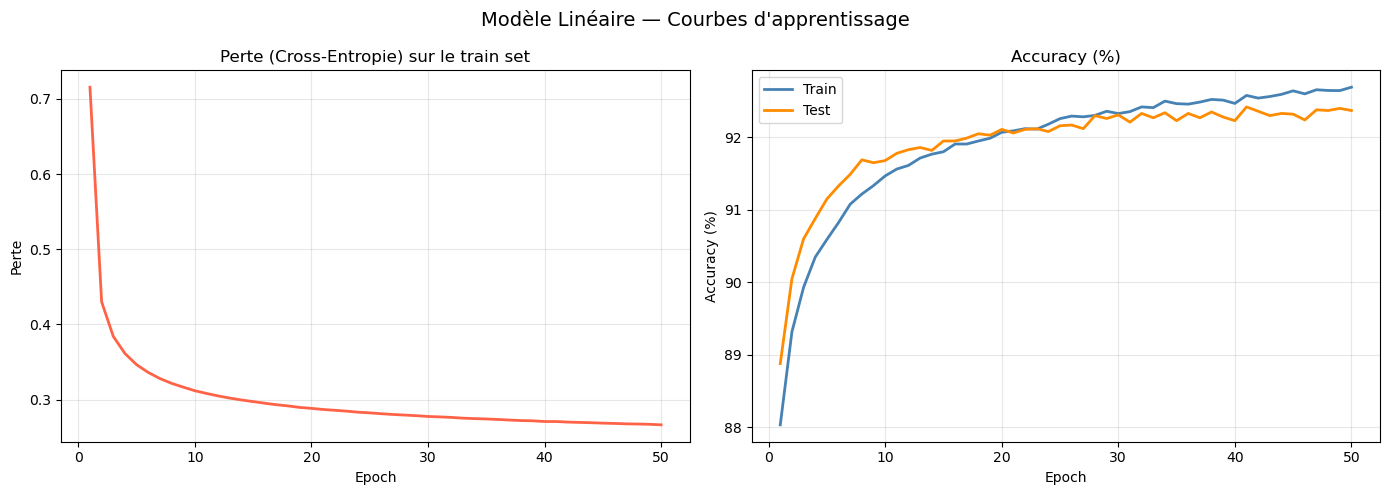


 Résultats finaux: Modèle Linéaire
   Accuracy sur le train : 92.69%
   Accuracy sur le test  : 92.37%
   Taux d'erreur test    : 7.63%


In [11]:
# Courbes d'apprentissage
epochs = range(1, len(modele_lineaire.historique_perte) + 1)
acc_train_lin = [a[0] for a in modele_lineaire.historique_accuracy]
acc_test_lin  = [a[1] for a in modele_lineaire.historique_accuracy]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Modèle Linéaire — Courbes d'apprentissage", fontsize=14)

ax1.plot(epochs, modele_lineaire.historique_perte, color='tomato', linewidth=2)
ax1.set_title('Perte (Cross-Entropie) sur le train set')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Perte')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, [a*100 for a in acc_train_lin], label='Train', color='steelblue', linewidth=2)
ax2.plot(epochs, [a*100 for a in acc_test_lin],  label='Test',  color='darkorange', linewidth=2)
ax2.set_title('Accuracy (%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Résultats finaux: Modèle Linéaire")
print(f"   Accuracy sur le train : {acc_train_lin[-1]*100:.2f}%")
print(f"   Accuracy sur le test  : {acc_test_lin[-1]*100:.2f}%")
print(f"   Taux d'erreur test    : {(1 - acc_test_lin[-1])*100:.2f}%")

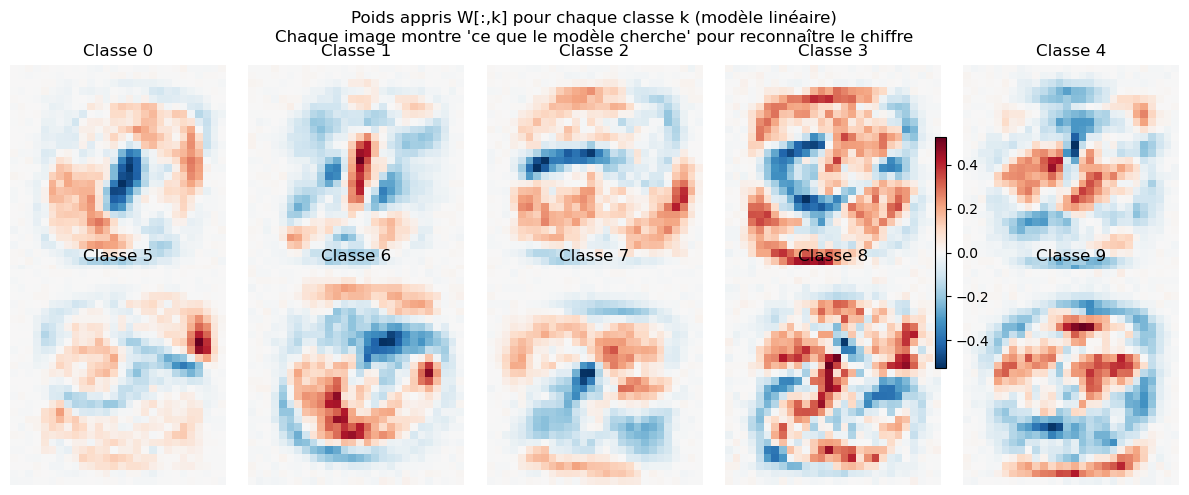

In [12]:
# Visualisation des poids appris - chaque poids W[:,k] est un filtre 28x28
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Poids appris W[:,k] pour chaque classe k (modèle linéaire)\n"
             "Chaque image montre 'ce que le modèle cherche' pour reconnaître le chiffre",
             fontsize=12)

for k, ax in enumerate(axes.flat):
    filtre = modele_lineaire.W[:, k].reshape(28, 28)
    im = ax.imshow(filtre, cmap='RdBu_r',
                   vmin=-np.abs(filtre).max(),
                   vmax= np.abs(filtre).max())
    ax.set_title(f'Classe {k}')
    ax.axis('off')

plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.tight_layout()
plt.show()

---
## 1.2.2 - Modèle à plusieurs couches (MLP)

### Principe

Un réseau de neurones **multi-couches** ajoute des **couches cachées** entre l'entrée et la sortie, avec des fonctions d'activation **non linéaires**.

**Architecture choisie :**
$$\text{entrée}(784) \xrightarrow{\text{linéaire}} \text{couche cachée 1}(256) \xrightarrow{\text{ReLU}} \xrightarrow{\text{linéaire}} \text{couche cachée 2}(128) \xrightarrow{\text{ReLU}} \xrightarrow{\text{linéaire}} \text{sortie}(10) \xrightarrow{\text{softmax}}$$

**Fonction d'activation ReLU :**  
$\text{ReLU}(z) = \max(0, z)$ — introduit la non-linéarité indispensable pour apprendre des représentations complexes.

### Rétropropagation

Pour mettre à jour les poids, on utilise la **règle de la chaîne** (chain rule) en remontant couche par couche.

In [14]:
# MODÈLE MLP - IMPLÉMENTATION FROM SCRATCH

def relu(Z):
    """ReLU : max(0, z). Introduit la non-linéarité."""
    return np.maximum(0, Z)

def relu_deriv(Z):
    """Dérivée de ReLU : 1 si z > 0, sinon 0."""
    return (Z > 0).astype(np.float32)


class MLP:
    """
    Réseau de neurones multi-couches (MLP) avec 2 couches cachées.
    
    Architecture :
        784 -> [Dense(256) + ReLU] -> [Dense(128) + ReLU] -> Dense(10)-> Softmax
    
    Implémentation from scratch de la rétropropagation du gradient.
    """

    def __init__(self, couches=(784, 256, 128, 10)):
        """
        couches : tuple donnant la taille de chaque couche.
                  par exemple: (784, 256, 128, 10) = entrée, 2 couches cachées, sortie
        """
        self.couches = couches
        self.n_couches = len(couches) - 1

        # Initialisation He : variance = 2 / n_entrees
        self.W = []
        self.b = []
        for i in range(self.n_couches):
            n_in  = couches[i]
            n_out = couches[i+1]
            w = np.random.randn(n_in, n_out).astype(np.float32) * np.sqrt(2.0 / n_in)
            b = np.zeros(n_out, dtype=np.float32)
            self.W.append(w)
            self.b.append(b)

        self.historique_perte    = []
        self.historique_accuracy = []

    def forward(self, X):
        """
        Passage avant. Retourne les probabilités softmax ET sauvegarde
        les activations intermédiaires pour la rétropropagation.
        """
        self.activations = [X]   # A[0] = entrée
        self.Z_cache     = []    # pré-activations (avant ReLU)

        A = X
        for i in range(self.n_couches):
            Z = A @ self.W[i] + self.b[i]   # pré-activation
            self.Z_cache.append(Z)

            if i < self.n_couches - 1:
                # Couches cachées : on applique ReLU
                A = relu(Z)
            else:
                # Dernière couche : on applique softmax
                A = softmax(Z)

            self.activations.append(A)

        return A   # probabilités softmax (N, 10)

    def backward(self, X, y_true):
        """
        Rétropropagation du gradient (backpropagation). On remonte de la sortie vers l'entrée.
        """
        N = len(y_true)
        probs  = self.activations[-1]   # sortie softmax
        Y_oh   = one_hot(y_true, K=10)

        # Gradient sur les logits de sortie (softmax + cross-entropie)
        dA = (probs - Y_oh) / N    # shape (N, 10)

        dW_list = []
        db_list = []

        # On remonte couche par couche (de la sortie vers l'entrée)
        for i in reversed(range(self.n_couches)):
            A_prev = self.activations[i]     # activation de la couche précédente

            dW = A_prev.T @ dA               # gradient sur les poids
            db = np.sum(dA, axis=0)          # gradient sur les biais
            dW_list.insert(0, dW)
            db_list.insert(0, db)

            if i > 0:
                # Propagation du gradient vers la couche précédente
                dA = dA @ self.W[i].T                    # (N, n_in)
                dA = dA * relu_deriv(self.Z_cache[i-1])  # dérivée de ReLU

        return dW_list, db_list

    def predict(self, X):
        """Retourne les classes prédites."""
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

    def entrainer(self, X_train, y_train, X_test, y_test,
                  lr=0.01, n_epochs=50, batch_size=256, verbose=True):
        """
        Entraînement par mini-batch SGD.
        """
        N = len(y_train)
        n_batches = N // batch_size

        if verbose:
            print(f"Architecture : {self.couches}")
            total_params = sum(w.size + b.size for w, b in zip(self.W, self.b))
            print(f"Nombre total de paramètres : {total_params:,}")
            print(f"Entraînement : {n_epochs} epochs, lr={lr}, batch_size={batch_size}")
            print(f"{'Epoch':>6} | {'Perte train':>12} | {'Acc train':>10} | {'Acc test':>10}")
            print("-" * 50)

        for epoch in range(n_epochs):
            indices = np.random.permutation(N)
            X_s, y_s = X_train[indices], y_train[indices]

            perte_epoch = 0.0
            for i in range(n_batches):
                Xb = X_s[i*batch_size:(i+1)*batch_size]
                yb = y_s[i*batch_size:(i+1)*batch_size]

                # Passage avant
                probs = self.forward(Xb)
                perte_batch = cross_entropy_loss(probs, yb)
                perte_epoch += perte_batch

                # Rétropropagation
                dW_list, db_list = self.backward(Xb, yb)

                # Mise à jour des paramètres
                for j in range(self.n_couches):
                    self.W[j] -= lr * dW_list[j]
                    self.b[j] -= lr * db_list[j]

            perte_moy = perte_epoch / n_batches
            acc_train = accuracy_score(y_train, self.predict(X_train))
            acc_test  = accuracy_score(y_test,  self.predict(X_test))

            self.historique_perte.append(perte_moy)
            self.historique_accuracy.append((acc_train, acc_test))

            if verbose and (epoch % 5 == 0 or epoch == n_epochs - 1):
                print(f"{epoch+1:>6} | {perte_moy:>12.4f} | {acc_train*100:>9.2f}% | {acc_test*100:>9.2f}%")

        return self


print("Classe MLP définie")

Classe MLP définie


In [15]:
# Entraînement du MLP
print("ENTRAÎNEMENT - MLP (2 couches cachées)")

debut = time.time()
mlp = MLP(couches=(784, 256, 128, 10))
mlp.entrainer(
    X_train, y_train,
    X_test,  y_test,
    lr=0.01,
    n_epochs=50,
    batch_size=256
)
duree_mlp = time.time() - debut
print(f"\nDurée d'entraînement : {duree_mlp:.1f}s")

ENTRAÎNEMENT - MLP (2 couches cachées)
Architecture : (784, 256, 128, 10)
Nombre total de paramètres : 235,146
Entraînement : 50 epochs, lr=0.01, batch_size=256
 Epoch |  Perte train |  Acc train |   Acc test
--------------------------------------------------
     1 |       1.5469 |     80.49% |     81.44%
     6 |       0.3411 |     90.69% |     91.23%
    11 |       0.2691 |     92.51% |     92.85%
    16 |       0.2297 |     93.64% |     93.93%
    21 |       0.2020 |     94.41% |     94.37%
    26 |       0.1807 |     94.95% |     94.84%
    31 |       0.1638 |     95.40% |     95.26%
    36 |       0.1496 |     95.86% |     95.55%
    41 |       0.1375 |     96.20% |     95.94%
    46 |       0.1272 |     96.47% |     96.13%
    50 |       0.1197 |     96.66% |     96.28%

Durée d'entraînement : 155.7s


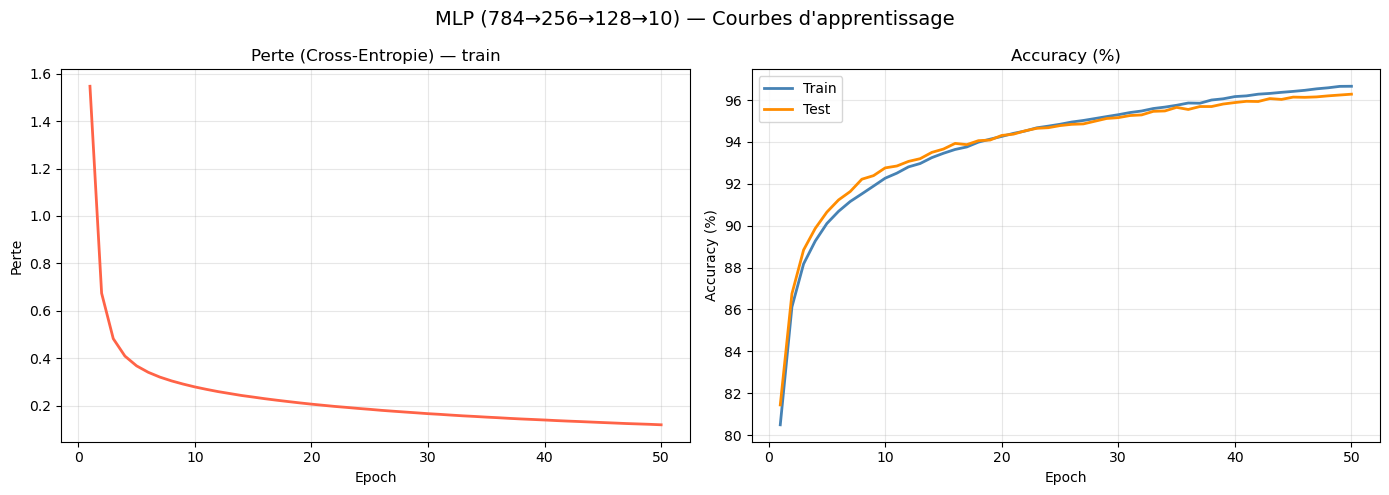


 Résultats finaux  MLP
   Accuracy sur le train : 96.66%
   Accuracy sur le test  : 96.28%
   Taux d'erreur test    : 3.72%


In [16]:
# Courbes d'apprentissage - MLP
epochs = range(1, len(mlp.historique_perte) + 1)
acc_train_mlp = [a[0] for a in mlp.historique_accuracy]
acc_test_mlp  = [a[1] for a in mlp.historique_accuracy]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MLP (784→256→128→10) — Courbes d'apprentissage", fontsize=14)

ax1.plot(epochs, mlp.historique_perte, color='tomato', linewidth=2)
ax1.set_title('Perte (Cross-Entropie) — train')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Perte')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, [a*100 for a in acc_train_mlp], label='Train', color='steelblue', linewidth=2)
ax2.plot(epochs, [a*100 for a in acc_test_mlp],  label='Test',  color='darkorange', linewidth=2)
ax2.set_title('Accuracy (%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Résultats finaux  MLP")
print(f"   Accuracy sur le train : {acc_train_mlp[-1]*100:.2f}%")
print(f"   Accuracy sur le test  : {acc_test_mlp[-1]*100:.2f}%")
print(f"   Taux d'erreur test    : {(1 - acc_test_mlp[-1])*100:.2f}%")

évaluation globale.


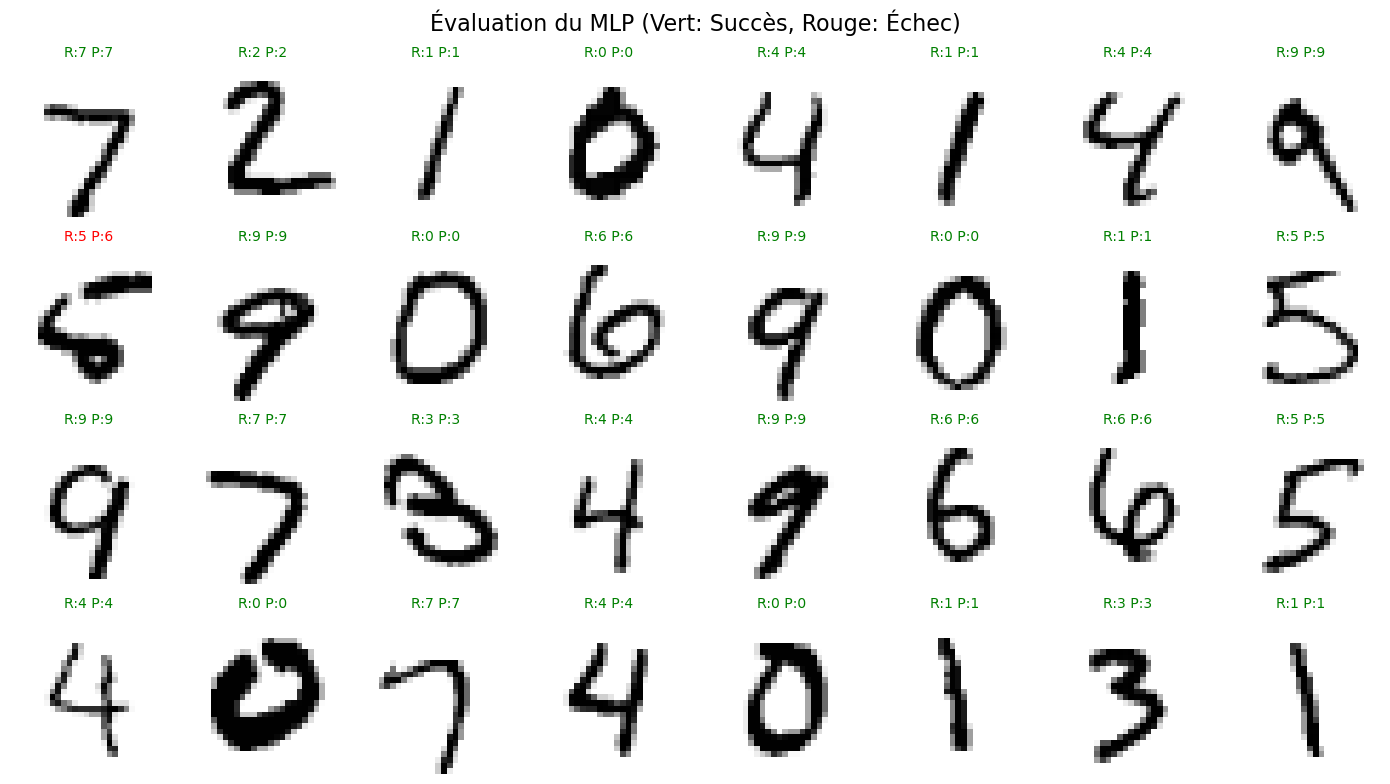

Nombre total d'erreurs sur le test set : 372 / 10000


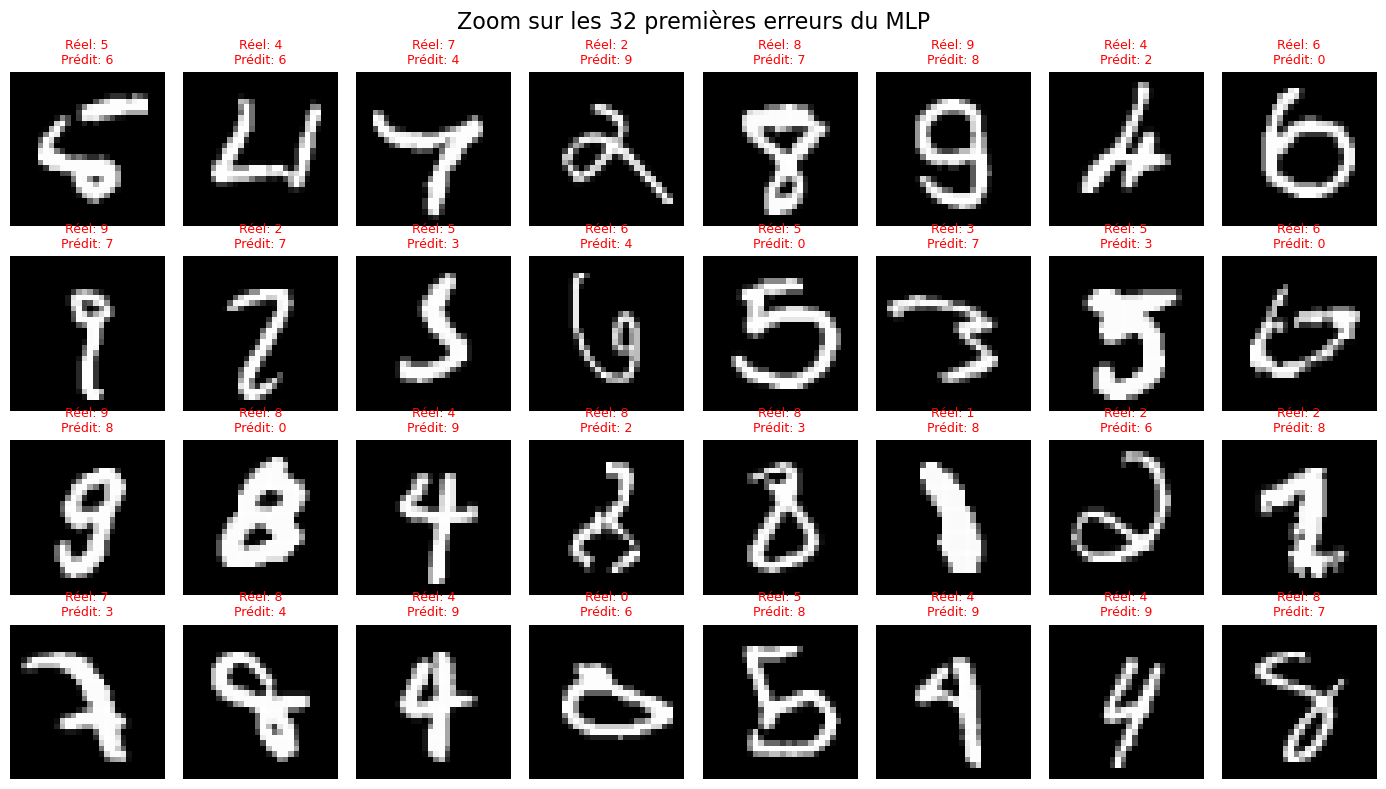

In [17]:
y_pred_mlp = mlp.predict(X_test)
#  Évaluation globale (Succès en vert, Erreurs en rouge) 
print("évaluation globale.")
fig1, axes1 = plt.subplots(4, 8, figsize=(14, 8))
fig1.suptitle("Évaluation du MLP (Vert: Succès, Rouge: Échec)", fontsize=16)

for i, ax in enumerate(axes1.flat):
    actual = y_test[i]
    predicted = y_pred_mlp[i]
    col = 'green' if actual == predicted else 'red'
    
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray_r')
    ax.set_title(f"R:{actual} P:{predicted}", fontsize=10, color=col)
    ax.axis('off')

plt.tight_layout()
plt.show()

# erreurs uniquement 
erreurs_idx = np.where(y_pred_mlp != y_test)[0]
print(f"Nombre total d'erreurs sur le test set : {len(erreurs_idx)} / {len(y_test)}")

fig2, axes2 = plt.subplots(4, 8, figsize=(14, 8))
fig2.suptitle("Zoom sur les 32 premières erreurs du MLP", fontsize=16)

for i, ax in enumerate(axes2.flat):
    idx = erreurs_idx[i]
    
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"Réel: {y_test[idx]}\nPrédit: {y_pred_mlp[idx]}", fontsize=9, color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 1.2.3 - Comparaison des résultats

On compare ici les deux modèles et on analyse leurs forces et faiblesses.

In [18]:
# Comparaison des modeles lineaire et MLP

acc_lin_train = acc_train_lin[-1]
acc_lin_test  = acc_test_lin[-1]
acc_mlp_train = acc_train_mlp[-1]
acc_mlp_test  = acc_test_mlp[-1]

n_params_lin = modele_lineaire.W.size + modele_lineaire.b.size
n_params_mlp = sum(w.size + b.size for w, b in zip(mlp.W, mlp.b))

print(f"{'COMPARAISON DES MODÈLES':^70}")
print("_" * 70)
print(f"{'':30} {'Linéaire':>15} {'MLP':>15}")
print("_" * 70)
print(f"{'Architecture':30} {'784→10':>15} {'784→256→128→10':>15}")
print(f"{'Nb de paramètres':30} {n_params_lin:>15,} {n_params_mlp:>15,}")
print(f"{'Accuracy train (%)':30} {acc_lin_train*100:>14.2f}% {acc_mlp_train*100:>14.2f}%")
print(f"{'Accuracy test (%)':30} {acc_lin_test*100:>14.2f}% {acc_mlp_test*100:>14.2f}%")
print(f"{'Taux erreur test (%)':30} {(1-acc_lin_test)*100:>14.2f}% {(1-acc_mlp_test)*100:>14.2f}%")
print("_" * 70)

                       COMPARAISON DES MODÈLES                        
______________________________________________________________________
                                      Linéaire             MLP
______________________________________________________________________
Architecture                            784→10  784→256→128→10
Nb de paramètres                         7,850         235,146
Accuracy train (%)                      92.69%          96.66%
Accuracy test (%)                       92.37%          96.28%
Taux erreur test (%)                     7.63%           3.72%
______________________________________________________________________


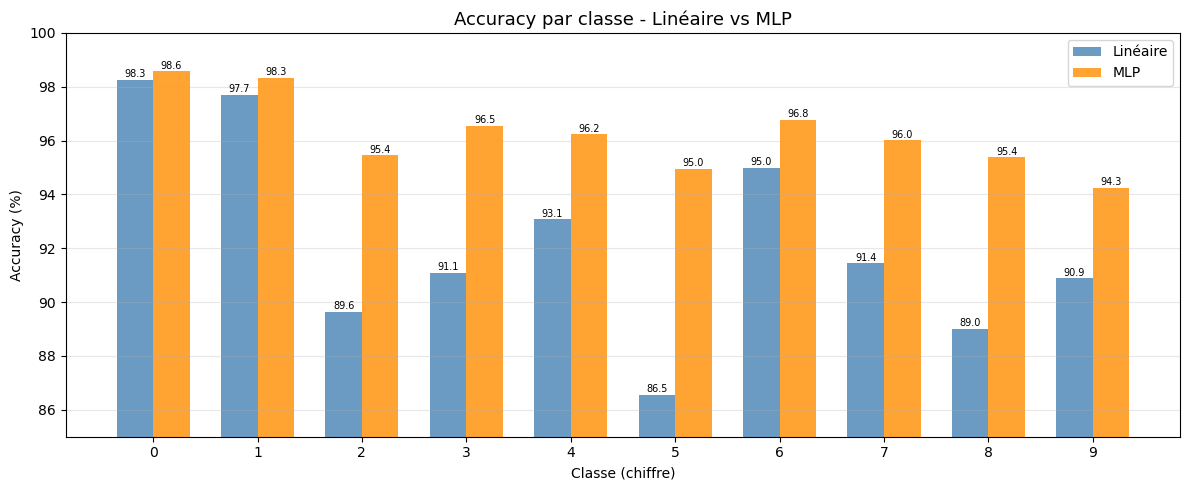

In [19]:
# GRAPHIQUE COMPARATIF - ACCURACY PAR CLASSE
y_pred_lin = modele_lineaire.predict(X_test)
# Précision par classe pour chaque modèle
acc_par_classe_lin = []
acc_par_classe_mlp = []

for k in range(10):
    mask = (y_test == k)
    acc_par_classe_lin.append(accuracy_score(y_test[mask], y_pred_lin[mask]))
    acc_par_classe_mlp.append(accuracy_score(y_test[mask], y_pred_mlp[mask]))

x = np.arange(10)
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - w/2, [a*100 for a in acc_par_classe_lin], w,
               label='Linéaire', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + w/2, [a*100 for a in acc_par_classe_mlp], w,
               label='MLP', color='darkorange', alpha=0.8)

ax.set_title('Accuracy par classe - Linéaire vs MLP', fontsize=13)
ax.set_xlabel('Classe (chiffre)')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(x)
ax.set_ylim(85, 100)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Valeurs au-dessus des barres
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}', ha='center', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

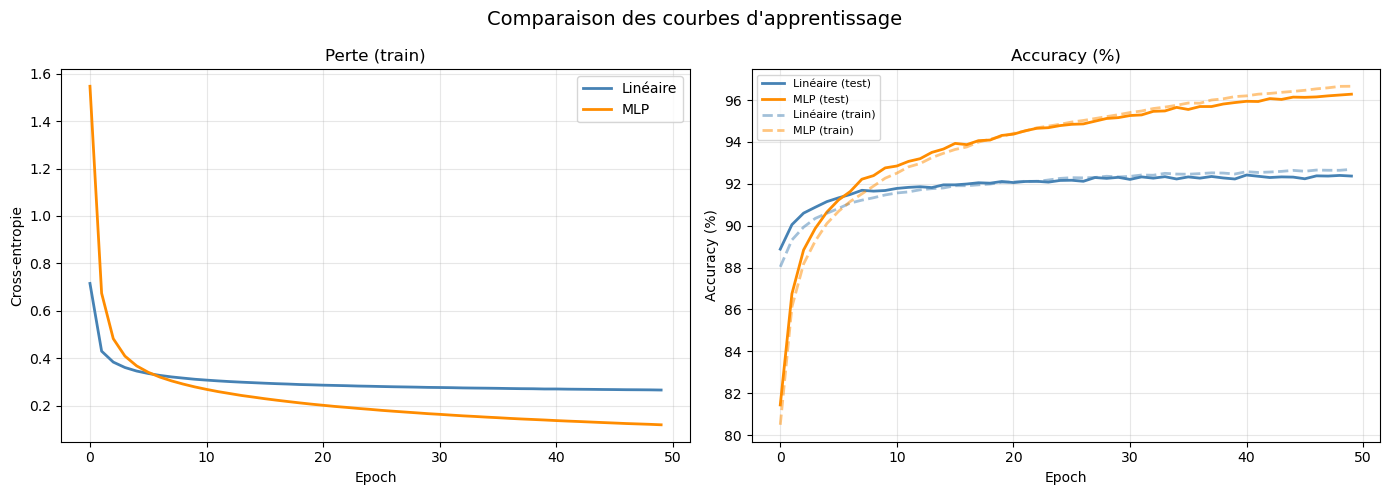

In [20]:
# COURBES D'APPRENTISSAGE SUPERPOSÉES

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparaison des courbes d'apprentissage", fontsize=14)

# Perte
axes[0].plot(modele_lineaire.historique_perte, label='Linéaire', color='steelblue', linewidth=2)
axes[0].plot(mlp.historique_perte,             label='MLP',      color='darkorange', linewidth=2)
axes[0].set_title('Perte (train)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropie')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy test
axes[1].plot([a[1]*100 for a in modele_lineaire.historique_accuracy],
             label='Linéaire (test)', color='steelblue', linewidth=2)
axes[1].plot([a[1]*100 for a in mlp.historique_accuracy],
             label='MLP (test)', color='darkorange', linewidth=2)
axes[1].plot([a[0]*100 for a in modele_lineaire.historique_accuracy],
             label='Linéaire (train)', color='steelblue', linewidth=2, linestyle='--', alpha=0.5)
axes[1].plot([a[0]*100 for a in mlp.historique_accuracy],
             label='MLP (train)', color='darkorange', linewidth=2, linestyle='--', alpha=0.5)
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()